#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from frank2d import *
from frank.utilities import UVDataBinner

#### Load data

In [2]:
dir = "../../data/uvtable/"
disk_name = "SimulatedBlob"
data_file = dir +"uvtable_SimulatedBlob.txt"

# Parameters for Geometry class, only for plotting purposes.
inc = 0
pa = 0
dra = 0
ddec = 0

rout = 1

# Load data
file = np.loadtxt(data_file, unpack =True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

In [3]:
q = np.hypot(uvtable['u'], uvtable['v'])
Qmax = np.max(q)

Rmax = 3*rout
N = get_optimal_N(Rmax, Qmax)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


### Let's explore Plot class using the results of 02_run_frank2d.ipynb

In [4]:
frank2d = Frank2D(N, Rmax, verbose = True)

In [5]:
best_Nopt_50 = {'m': np.float64(-1.11786744524583),
 'c': np.float64(2114.0760515814472),
 'l': np.float64(56439.32547348452)}

In [6]:
frank2d.fit(data = uvtable, kernel_params = best_Nopt_50)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
         + Kernel parameters: {'m': np.float64(-1.11786744524583), 'c': np.float64(2114.0760515814472), 'l': np.float64(56439.32547348452)}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.77 seconds
        +  Building system = 0.03  min |  1.82 seconds
===>  Solving linear system...


        +  Fitting:   0%|          | 217/50000 [00:18<1:09:09, 12.00 iterations/s]


        +  Fit info: 
              'CGM_converged': True,
               'Fit_correctly': False,
               'convergence_by': 'norm of r',
               'final_tol': 7.435963551417658,
               'iterations': 217,
               'maxiter': 50000,
               'preconditioner_method': 'jacobi',
               'rtol': 1e-08,
               'solver_method': 'bicgstab',
               'solver_time_sec': 18.09338903427124
===> Building full visibility model...
     + Setting kernel..


### Frankenstein2D: Plot Class

To use the `Plot` class for visualization, you must provide it with your fitted `Frank2D` object, which contains both the modeled visibilities and the reconstructed intensity solutions. 

Additionally, you need to pass a `Geometry` object. Providing the geometry is essential, as it allows the `Plot` class to perform accurate deprojections or apply necessary phase corrections directly in the visibility space before plotting.

In [7]:
geom = Geometry(inc, pa, dra, ddec)
Plotter = Plot(frank2d, geom)

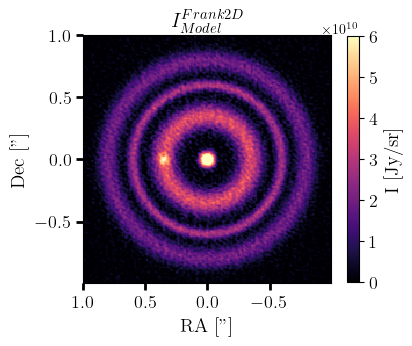

In [8]:
Plotter.intensity(fig_size=4, vmax=6e10, gamma = 1, zoom = 3, title = r'$I_{Model}^{Frank2D}$', title_size = 15)

**We can run internally frank1d with the default hyperparameters in the frank1d method of the Frank2d class**

In [9]:
help(frank2d.frank1d)

Help on method frank1d in module frank2d.cpu.frank2d:

frank1d(geom, data=None, rout=None, alpha=1.05, w_smooth=0.001, n_pts=300) method of frank2d.cpu.frank2d.Frank2D instance
    Perform a 1D Frank fit on the visibility data.
    Parameters:
    -----------
    geom : Geometry object
        Geometry object containing source geometry parameters.
    data : dict
        Dictionary containing 'u', 'v', 'vis' and 'weights' keys.
        u : 1D array, unit: lambda
            u coordinates of the visibility data.
        v : 1D array, unit: lambda
            v coordinates of the visibility data.
        Vis : 1D array,  unit: Jy
            Visibility data.
        Weights : 1D array, unit: 1/Jy^2
            Weights of the visibility data.
    rout : float
        Outer radius for the 1D Frank fit in arcseconds.
    alpha : float
        Power-law index for the visibility fitting.
    w_smooth : float
        Smoothing weight for the visibility fitting.
    n_pts : int
        Number o

[WARNING] Frank1D profile not set.Using gridded visibilities as inputAnd default parameters of frank1d method of Frank2D Class.
Use the 'set_f1d_solution' method to set the Frank1D solution to be plotted.


===> Performing 1D Frank fit

        + $\alpha$ = 1.05 and $w_{smooth}$ = 0.001

        + N = 642


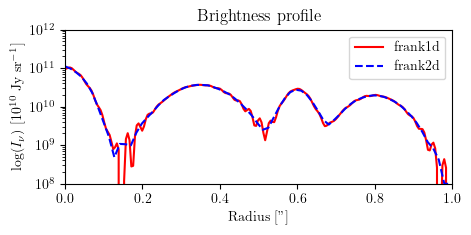

In [10]:
Plotter.intensity_profile(fig_size = (5, 2), x_lims = (0, 1), y_lims = (1e8, 1e12), frank1d = True)

**or we can upload the solution or run it directly from the frank1d method**

In [11]:
dir_f1d = "../../data/f1d/"

import pickle
f1d_file = dir_f1d + "f1d_Simulated_N642_rout3_alpha1.2_ws0.001.pickle"
with open(f1d_file, 'rb') as handle:
    frank1d_sol = pickle.load(handle)

Plotter.set_f1d_solution(frank1d_sol)


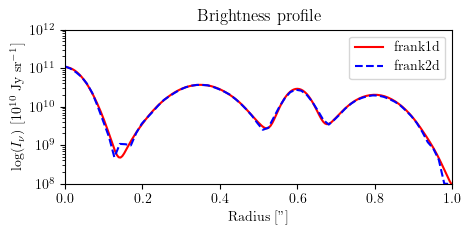

In [12]:
Plotter.intensity_profile(fig_size = (5, 2), x_lims = (0, 1), y_lims = (1e8, 1e12), frank1d = True)

**We can also compare directly with the CLEAN model given a .fits file**

For that, we need to introduce the FWHM of the models to compare with, this is, Frankenstein1D and/or Frankenstein2D. Roughly we know Frankenstein2D is half of the CLEAN beam size and Frankesntein1D a third of the CLEAN beam size. In this example we use the values obtain in the 03_fwhm_frank2d.py file.

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


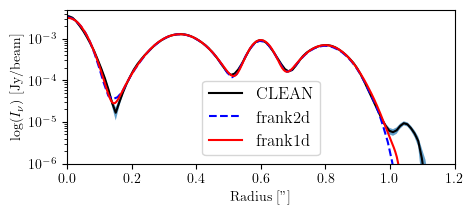

In [13]:
dir_clean_file = "../../data/.image_fits/SimulatedBlob_dotimage_imsize642_cellsize0p009.fits"
Plotter.set_fits_file(dir_clean_file)

Plotter.intensity_profile( fig_size = (5, 2),  frank1d = True,
                           f1d_fwhm = 13e-3, f2d_fwhm = 22.7e-3,
                           clean = True)

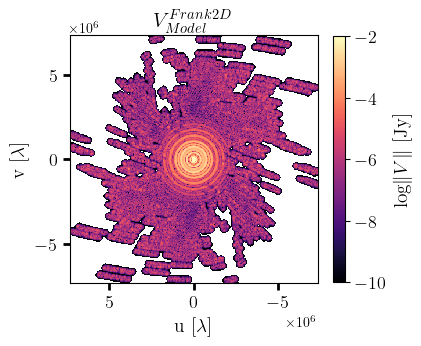

In [14]:
Plotter.visibility(fig_size=4, zoom = 1.5, title= r'$V_{Model}^{Frank2D}$', title_size = 15)

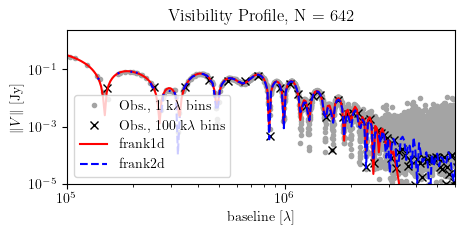

In [15]:
Plotter.visibility_profile( fig_size = (5, 2), weighted  = False, frank1d = True)

In [16]:
initial_guess = {'logp': -0.5, 'logq': 5,  'm': -1, 'l': 1e4}

 Also, instead, we could have used directly `frank2d.fit(find_MAP= True, initial_guess = guess)` 

In [17]:
frank2d.search_MAP(initial_guess= initial_guess, N_opt = 50)

[WARNING] Using existing visibility data...


===>  Setting MAP estimator...
===>  Searching for MAP...
         + MAP found: {'m': np.float64(-1.1178679332923875), 'c': np.float64(2113.9899790849863), 'l': np.float64(56438.659496007334)}


### The log-posterior probability terms
   
   $\log P(\theta | V_{\text{obs}})
    = {\color{yellow}{\log\!\left|\frac{D}{2\pi N S}\right|^{1/2}
    + \frac{j^{\dagger}\mu}{2}
    + \log P(\theta)}}
    - \frac{V_{\text{obs}}^{\dagger} N^{-1} V_{\text{obs}}}{2}
    - \log P(V_{\text{obs}})$


To find the optimal hyperparameters $\theta$ of the model, the goal is to maximize the posterior probability $\log P(\theta | V_{\text{obs}})$. In optimization practice, this is equivalent to finding the minimum of the negative log-likelihood, that is, minimizing $-\log P(\theta | V_{\text{obs}})$.

When analyzing the expansion of the probability, we note that the last two terms ($\frac{1}{2}V_{\text{obs}}^{\dagger} N^{-1} V_{\text{obs}}$ and $\log P(V_{\text{obs}})$) are constant with respect to the hyperparameters $\theta$, as they depend purely on the fixed data and the noise. Therefore, when taking the derivative to find the minimum, these terms disappear. 

The objective function $\mathcal{L}(\theta)$ that actually matters for the minimization depends exclusively on the highlighted terms:

$$\mathcal{L}(\theta) = - \left( \frac{1}{2} \log\left|\frac{D}{2\pi N S}\right| + \frac{1}{2} j^{\dagger}\mu + \log P(\theta) \right)$$

To evaluate this function, we connect it directly to the linear algebra definitions established in Jennings et al. 2020. Knowing that the posterior mean is given by $\mu = D j$, we can rewrite the central term as $j^{\dagger} \mu = j^{\dagger} D j$. Breaking down the components, we have:

* **The data-projected vector ($j$)**: Defined as $j = \mathbf{H}^T \mathbf{N}^{-1} V^{\text{observed}}$.
* **The information matrix ($\mathbf{M}$)**: Defined as $\mathbf{M} = \mathbf{H}^T \mathbf{N}^{-1} \mathbf{H}$.
* **The Gaussian Process covariance ($\mathbf{S}$) in real space**: This matrix evaluates the spatial kernel and is the component that directly depends on the hyperparameters $\theta$ we are optimizing.
* **The posterior covariance ($D$)**: It combines the observational information matrix with the GP covariance, defined as $D = (\mathbf{M} + \mathbf{S})^{-1}$.

Substituting $D$, the data-fit term $j^{\dagger} D j$ takes the explicit form $j^{\dagger} (\mathbf{M} + \mathbf{S})^{-1} j$. This term measures how well the predictions fit the projected data, while the determinant term $\log|D / (2\pi N S)|$ acts as a natural penalty for model complexity (preventing overfitting), and $\log P(\theta)$ provides the prior information about the parameters, that is 0 in our model.

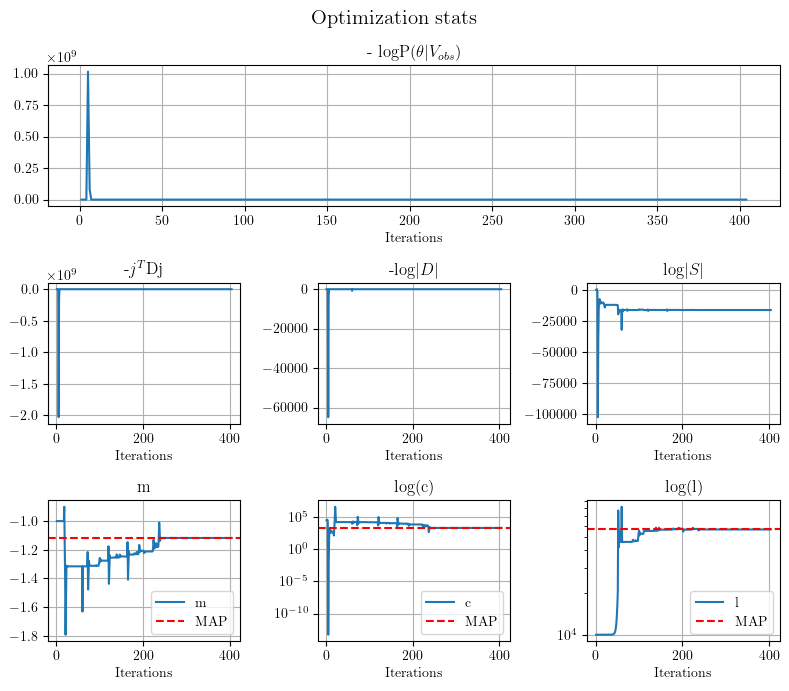

In [18]:
Plotter.stats_optimization()